Name: Yamini M
Reg No: 24BAD131
Best K: 11
Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



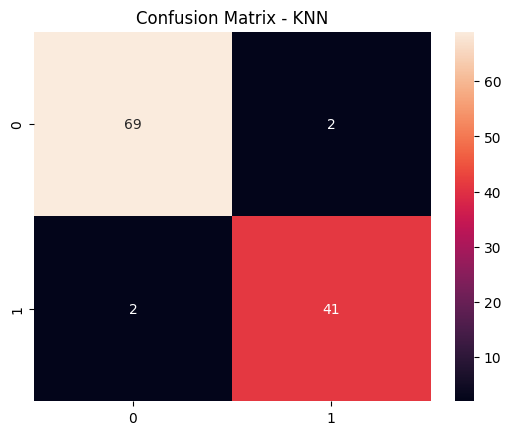

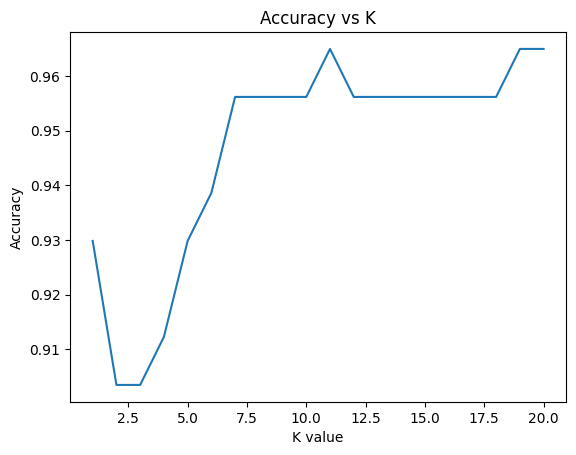

Number of Misclassified Cases: 4


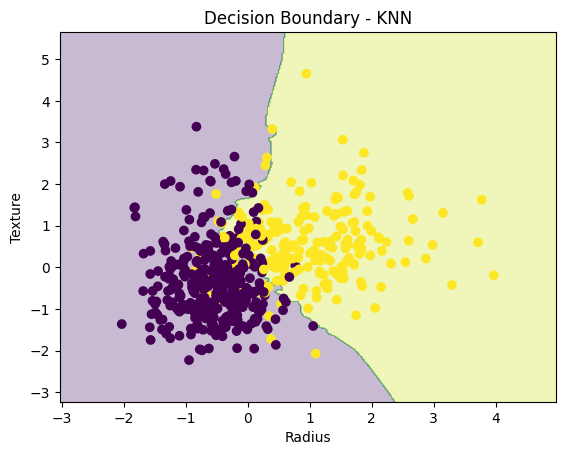

In [ ]:
print("Name: Yamini M")
print("Reg No: 24BAD131")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("breast-cancer.csv")

features = ['radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean']
X = df[features]
y = df['diagnosis']

le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

k_values = range(1,21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

best_k = k_values[np.argmax(accuracies)]
print("Best K:", best_k)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - KNN")
plt.show()

plt.figure()
plt.plot(k_values, accuracies)
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

misclassified = np.where(y_test != y_pred)
print("Number of Misclassified Cases:", len(misclassified[0]))

X2 = df[['radius_mean','texture_mean']]
X2_scaled = scaler.fit_transform(X2)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_scaled, y, test_size=0.2, random_state=42)

knn2 = KNeighborsClassifier(n_neighbors=best_k)
knn2.fit(X2_train, y2_train)

h = .02
x_min, x_max = X2_scaled[:, 0].min() - 1, X2_scaled[:, 0].max() + 1
y_min, y_max = X2_scaled[:, 1].min() - 1, X2_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2_scaled[:, 0], X2_scaled[:, 1], c=y)
plt.xlabel("Radius")
plt.ylabel("Texture")
plt.title("Decision Boundary - KNN")
plt.show()

Name: Yamini M
Reg No: 24BAD131
Best Depth: 1
Accuracy: 0.7886178861788617
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



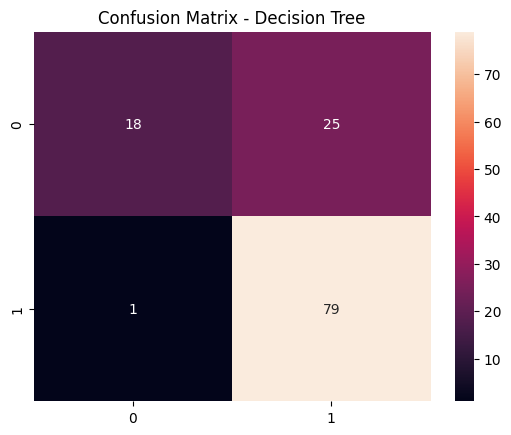

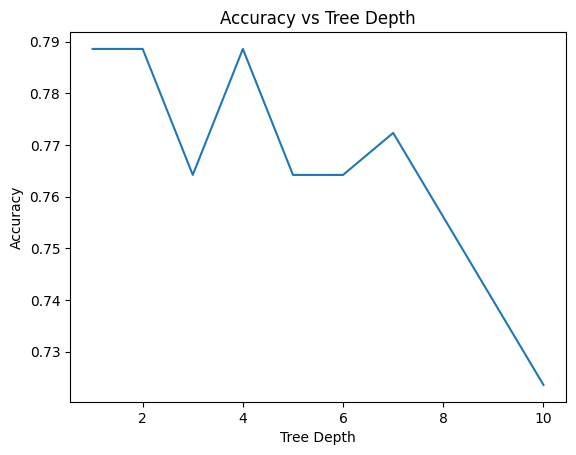

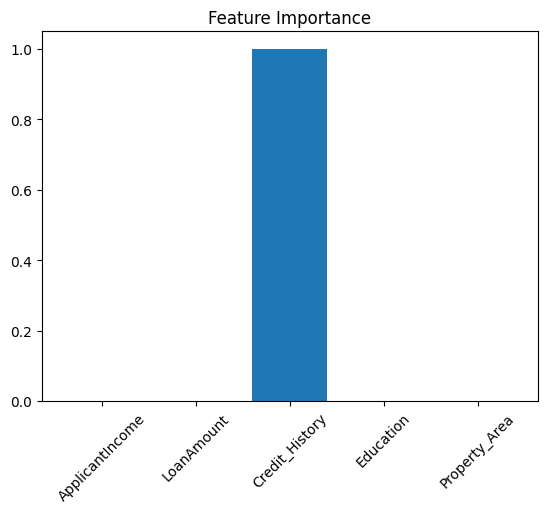

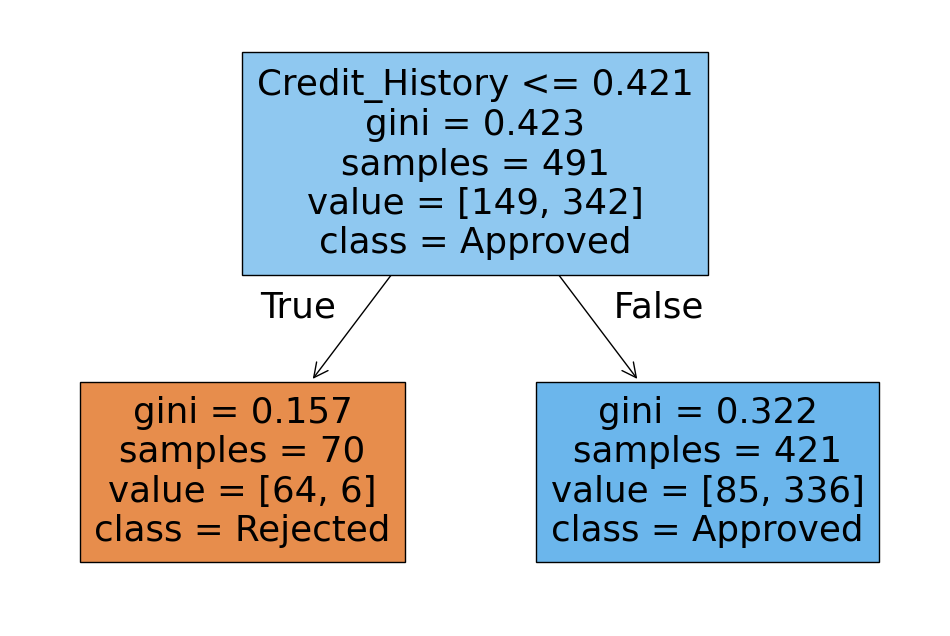

In [ ]:
print("Name: Yamini M")
print("Reg No: 24BAD131")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("loan.csv")

features = ['ApplicantIncome','LoanAmount','Credit_History','Education','Property_Area']
X = df[features].copy()
y = df['Loan_Status'].copy()

X = X.fillna(X.mean(numeric_only=True))
X = X.fillna("Unknown")

for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

le_target = LabelEncoder()
y = le_target.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

depths = range(1,11)
accuracy_list = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    accuracy_list.append(accuracy_score(y_test, y_pred))

best_depth = depths[np.argmax(accuracy_list)]
print("Best Depth:", best_depth)

dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

plt.figure()
plt.plot(depths, accuracy_list)
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Depth")
plt.show()

importances = dt.feature_importances_
plt.figure()
plt.bar(features, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=features, class_names=["Rejected","Approved"], filled=True)
plt.show()